##### Instructions
- Keep the original structure, you may add additional code cells and/or mark-down cells for clarity, legibility and/or structure.
- Add the required descriptions, explanations, justifications to the mark-down cells. You can find more mark-down tips & tricks online, for example [here](https://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Working%20With%20Markdown%20Cells.html) and [here](https://www.ibm.com/docs/en/watson-studio-local/1.2.3?topic=notebooks-markdown-jupyter-cheatsheet)

# EXAM03: Data Science Group Assignment - Iteration 2

**Group name:** The Secret Weapons

**Student names & numbers:**
* Scott Mulder - 101232
* Sidney Felius - [Student no.]
* Valentijn van Grunsven - [Student no.]


---

## 0. Iteration setup

**Import libraries**

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

**Load and merge datasets**

In [2]:
df_inventory = pd.read_csv('data/ships_inventory_iter1.csv')
df_inspections = pd.read_csv('data/ship_inspections_iter2.csv')
df = pd.merge(df_inventory, df_inspections, on='Ship_ID', how='inner')

---

## 1. Business Understanding
*Rubric: LO 6.4D (Reflection on Process)*

**Situation description**
<br>
<sub>*Describe the problem surrounding the safety inspections. Why is the current process (human estimation/gut feeling) a risk?*</sub>

As stated in the case, there are 3 major problems with the 2nd dataset. 

It's disconnected from the first set (which isnt a huge deal, since merging it is quite easily achievable). 

Secondly it has corrupted data. This is a much bigger problem, cause without the right data there will be less to work with, but also it is quite important that you do have the right data, otherwise you might start making wrong guesses or estimations about ships that aren't illegal or causing any problems. 

Finally the ratings. this is moreso an annoyance than really a major safety issue. You can give the ships a "Green/Yellow/Red" based on the data that you see. Now as stated earlier, there is data missing, so this isnt as easy as it sounds, but it should be manageable. 

all of this is a risk because if you're going to use corrupt data as your in, then you will get corrupt data or corrupt advice out. This means that you will start applying fixes for problems that are generated by the dataset, and not by what is actually happening.

**Business objective(s)**
<br>
<sub>*Justify why a standardized, rule-based expert system is needed.*</sub>

First of all, we will be using a standardized, rule-based expert system because It's transparent. Every decision made can be traced back to the model, and you can clearly see why a ship would be pristine, or why it would be critical (for example if age < 7500 ship = pristine). This helps build trust with stakeholders, and also makes it easy to reason as to why this ship is considered pristine.

Secondly, it will handle the missing and corrupt data. You can instate rules that handle the missing values, such as taking the mean or doing a forward fill. You can also choose which version of handling the corrupt data you want to do per section. This makes it super flexible

Finally, Consistency. When you standardize a system, you make sure that, even if the data is messy, your (in this case) ships are handled and evaluated in the same way. This is also very important for the finalization of the data, where the sales team just wants a simple "green/yellow/red" to have an easier time choosing what to do with which ships.

**Data mining goal(s)**
<br>
<sub>*Explain what type of modeling task this is and why.*</sub>

This is a classification modeling task that we are performing. You could say that it is a regression cause you're looking at the numbers of the wear. but in the end it is about the state of the space ship (pristine, operational, critical). With regression you would predict a number such as reactor power or galactic credits. It maps features such as those to the categories mentioned before, that's why it falls into the category of classification model.

**Success criteria**
<br>
<sub>*Determine success criteria for this iteration*</sub>

We have decided that the success criteria for this iteration will be <br>
1. That the data will be properly integrated, properly clean up the missing and corrupted values and handling the outliers in the new dataset.<br>
2. We will have a rule-based classification system with consistent rules that make for an explainable and streamlined way to categorize the ships <br>
3. There will be no Null labels in our dataset. if one is given a null label, we will make sure that there will be fixed. Either by adding a new rule for cases like those, or checking wether the 1st success criteria was executed properly.

In short: success will be achieved if the dataset is cleaned up, properly filled in and spits out proper pristine / operational / critical labels with proof to back up why this is the case.

---

## 2. Data Understanding
*Rubric: LO 7.3Q (Visuals) & LO 6.4C (Process)*

**Data exploration**
<br>
<sub>*Show the summary statistics and describe the new variables (e.g., Propulsion_Type, Reactor_Power, Hull_Integrity). Describe your findings.*</sub>



In [3]:
print("First five rows of the dataset:")
display(df_inspections.head(5))

print("Dataset Information:")
df_inspections.info()

print("Description of the dataset:")
df_inspections.describe(include=['object'])


First five rows of the dataset:


,Ship_ID,Hull_Integrity,Reactor_Power,Propulsion_Type,Ship_Class
0,7316814884,Operational,80.0,Ion Drive,Hauler
1,7316814758,Operational,80.0,Hyperdrive,Hauler
2,7316814989,Pristine,80.0,Hyperdrive,Hauler
3,7316743432,Pristine,80.0,Plasma Thruster,Hauler
4,7316356412,Operational,60.0,Ion Drive,Freighter


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 368315 entries, 0 to 368314
Data columns (total 5 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Ship_ID          368315 non-null  int64  
 1   Hull_Integrity   368315 non-null  object 
 2   Reactor_Power    338877 non-null  float64
 3   Propulsion_Type  311705 non-null  object 
 4   Ship_Class       368315 non-null  object 
dtypes: float64(1), int64(1), object(3)
memory usage: 14.1+ MB
Description of the dataset:


,Hull_Integrity,Propulsion_Type,Ship_Class
count,368315,311705,368315
unique,3,8,8
top,Operational,Ion Drive,Shuttle
freq,141273,177374,125707


As you can see here there are a few new variables. In short they are

Hull Integrity: This is the state of the hull of the ship. a.k.a. what is the quality of the ship <br>
Reactor Power: How strong is the reactor that powers the ship, also would impact the speed (but outside of the scope of this project) <br>
Propulsion Type: The type of propulsion the ship uses (this is affected by the supplier) <br>
Ship Class: This is what type of ship we're dealing with. so a cargo ship or a for fun ship f.e. <br>

From the small amount of Describing and looking at the dataset, we can conclude that alot of the ships are Ion Drive, and alot of them are shuttles. maybe these have overlap, but could mean anything. One thing is for sure though, Ion Drive is very popular. either for quality, or for price performance.

**Visualizations and patterns**

*Discover patterns in the data that will help you determine the inspection rules. Create visualizations that show the relationship between variables like Reactor_Power, Propulsion_Type, Ship_Class on one side, and the target variable Hull_Integrity on the other. Describe any hard rules you discover (e.g., relationships with dangerous reactors or advanced tech).*

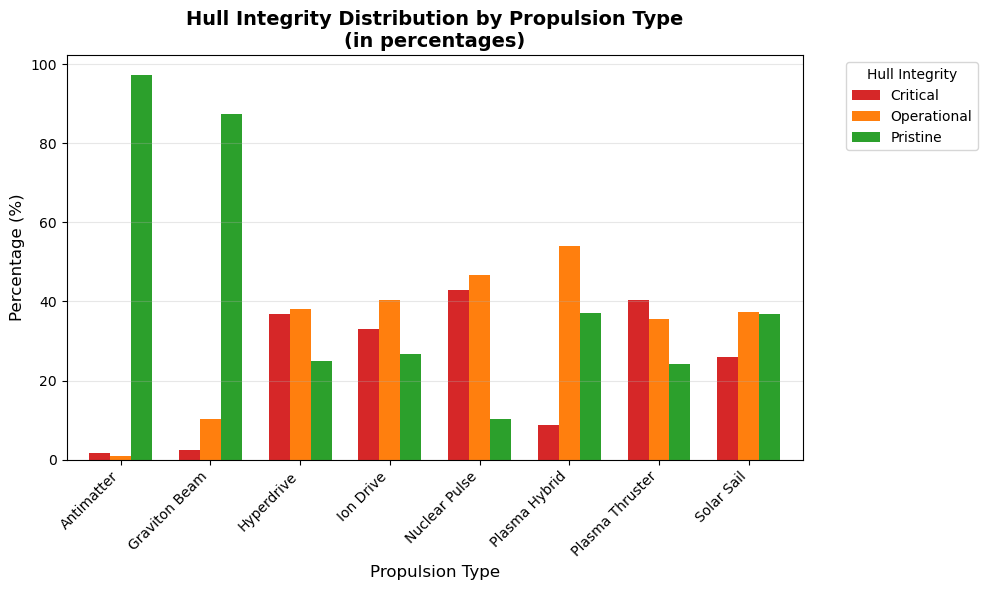

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#d62728', '#ff7f0e', '#2ca02c']
propulsion_hull_pct = pd.crosstab(df['Propulsion_Type'], df['Hull_Integrity'], normalize='index') * 100
propulsion_hull_pct.plot(kind='bar', ax=ax, color=colors, width=0.7)

ax.set_title('Hull Integrity Distribution by Propulsion Type\n(in percentages)', fontsize=14, fontweight='bold')
ax.set_xlabel('Propulsion Type', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(title='Hull Integrity', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

As you can see here, i have made the distribution between all the different propulsion types, and the status of the hull. You can see here that its pretty even. the only thing that is really sticking out is 

Antimatter and Graviton Beam are very highly performing. This could mean a few things. Either A. They are very good and very safe, so every ship **should** be using these. B. these are very new, so only installed in very new ships. People are maybe already caught on that this is the new best thing. or C. this is a very high-end luxury propulsion type, which means that only the most expensive ships have these.

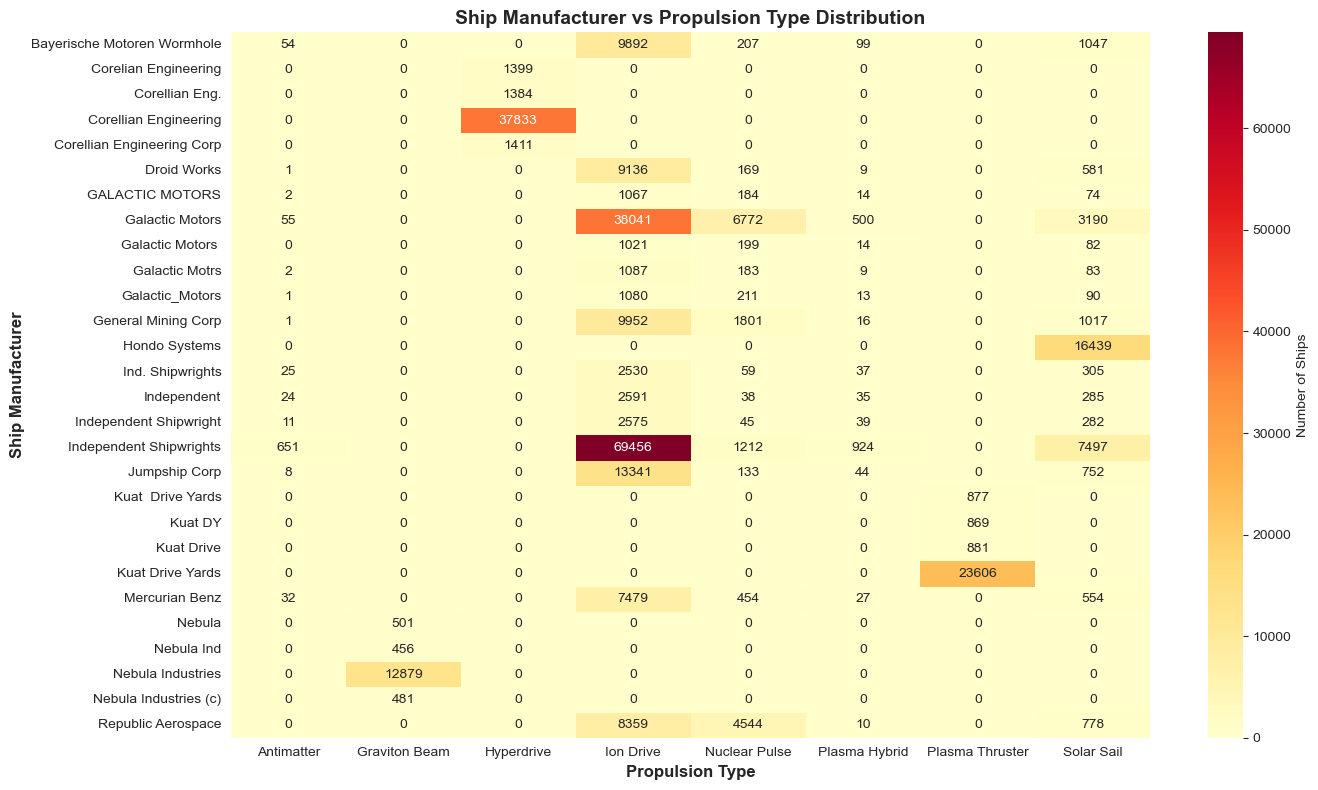

In [55]:
# Manufacturer vs Propulsion Type Analysis
fig, ax = plt.subplots(figsize=(14, 8))

# Create crosstab of manufacturer and propulsion type
mfg_prop = pd.crosstab(df['Ship_Manufacturer'], df['Propulsion_Type'])

# Create heatmap
sns.heatmap(mfg_prop, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Number of Ships'}, ax=ax)

ax.set_title('Ship Manufacturer vs Propulsion Type Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Propulsion Type', fontsize=12, fontweight='bold')
ax.set_ylabel('Ship Manufacturer', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

As you can see for this Heatmap, alot of the manufacturers are in the dataset multiple times because of typos (this will be fixed in Data Preperation). 

The more interesting part is to see that some propulsion types are almost exclusively used by some manufacturers. Take Graviton Beam for example. this propulsion type is only used by nebula industries. This makes sense, cause you wouldnt want to share your very premium and well tested (as seen in the first visualisation) with your competitors.

This could mean that either the dataset is not correct, it would be missing values for some companies. A good example of this being Corellian Engineering. They would only have Hyperdrive, which is possible, but could be a mistake since most of the other companies do have *some* other ships. We could do this by either applying domain knowledge (which i think is the best in this situation). or you could do a forward fill, but this would create some strange occurences of a company having 1 propulsion type 99% of the time, and then having 1 ship that has something else.

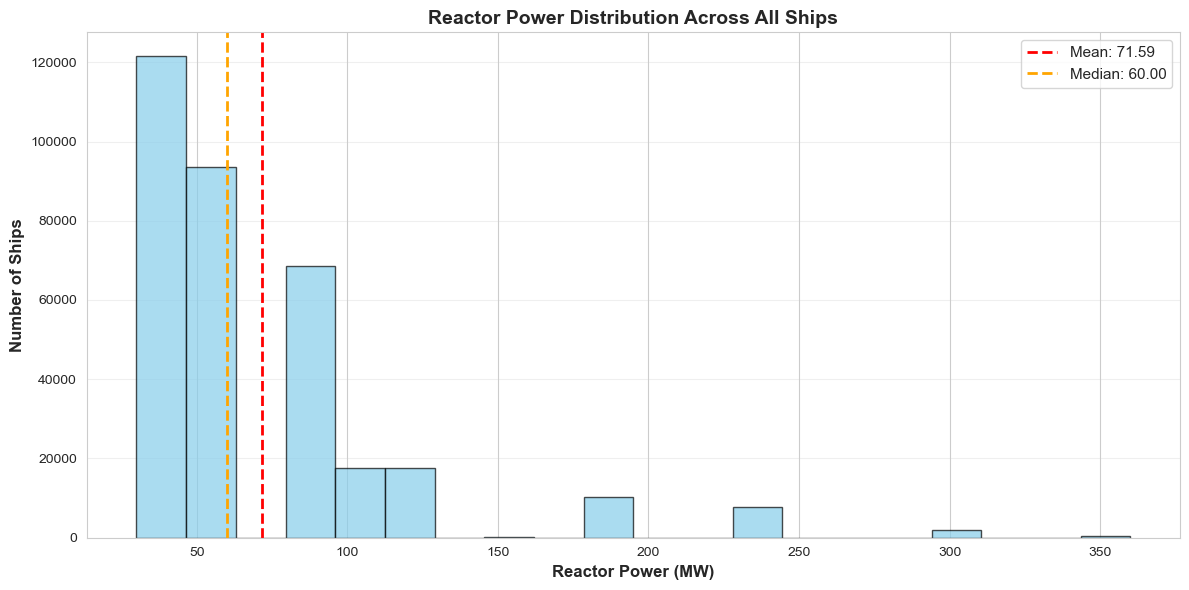

Reactor Power Statistics:
Min: 30.0
Max: 360.0
Mean: 71.59
Median: 60.00
95th Percentile: 180.00


In [62]:
# Reactor Power Distribution Histogram
fig, ax = plt.subplots(figsize=(12, 6))

# Create histogram with appropriate binning to reveal distribution shape
ax.hist(df['Reactor_Power'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)

# Add mean and median lines
mean_power = df['Reactor_Power'].mean()
median_power = df['Reactor_Power'].median()
ax.axvline(mean_power, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_power:.2f}')
ax.axvline(median_power, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_power:.2f}')

ax.set_title('Reactor Power Distribution Across All Ships', fontsize=14, fontweight='bold')
ax.set_xlabel('Reactor Power (MW)', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Ships', fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Display basic statistics
print(f"Reactor Power Statistics:")
print(f"Min: {df['Reactor_Power'].min()}")
print(f"Max: {df['Reactor_Power'].max()}")
print(f"Mean: {mean_power:.2f}")
print(f"Median: {median_power:.2f}")
print(f"95th Percentile: {df['Reactor_Power'].quantile(0.95):.2f}")


For the final plot you can see the reactor power is very skewed to the right. From the small stats that you get under the graph, you can see that the 95 percentile is very low compared to the maximum number that you get from the dataset (namely, 360). this means that some ships are very overtuned, or are wrongly put in the dataset. seeing as they still have a few hundred entries, it's pretty safe to assume that they are correct, and illegal ships that are very overtuned. 

---

## 3. Data Preparation
*Rubric: LO 6.4C (Data Science Steps)*

**Cleaning and preprocessing**
*Describe and justify how you resolve the missing values.*

In [15]:

print("Dataset A:", len(df_inventory['Ship_ID'].unique()))
print("Dataset B:", len(df_inspections['Ship_ID'].unique()))
print("Merged:", len(df['Ship_ID'].unique()))

Dataset A: 368314
Dataset B: 368315
Merged: 368314


Voor de merge is een inner join gebruikt om ervoor te zorgen dat er alleen ships werden gebruikt die in beide datasets komen. tijdens de merge zijn er bijna geen schepen verloren (1 schip viel af) dit betekent dat de merge succesvoll was en er bijna geen data verloren is.

**Imputation Strategy**

**Propulsion_Type:**<br>
*Approach:* Mode <br>
*Justification:* Propulsion_Type using mode is appropriate because:
Missing propulsion type is likely random, so replacing with the most common type is a reasonable assumption. Alternative approaches like dropping rows would lose valid ship data creating a unkown category with unrealistic data


**Reactor_Power:**<br>
*Approach:* Median <br>
*Justification:* Median was selected over mean because the Reactor_Power distribution has outliers, making median a better option than the mean. This prevents unrealistic reactor power assignments that could influence the classification model


In [7]:
# Check for missing values before cleaning
print("Missing values BEFORE cleaning:")
print(df[['Galactic_Credits', 'Model_Cycle', 'Propulsion_Type', 'Reactor_Power', 'Hull_Integrity']].isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

# 1. Propulsion_Type: Fill with mode (most frequent value)
propulsion_mode = df['Propulsion_Type'].mode()[0]
df['Propulsion_Type'] = df['Propulsion_Type'].fillna(propulsion_mode)
print(f"Propulsion_Type missing values filled with mode: '{propulsion_mode}'")

# 2. Reactor_Power: Fill with median (robust to outliers)
df['Reactor_Power'] = df['Reactor_Power'].fillna(df['Reactor_Power'].median())
print(f"Reactor_Power missing values filled with median: {df['Reactor_Power'].median()}")

# 3. Model_Cycle: Fill with median (preserves distribution)
df['Model_Cycle'] = df['Model_Cycle'].fillna(df['Model_Cycle'].median())
print(f"Model_Cycle missing values filled with median: {df['Model_Cycle'].median()}")

# Convert data types
df['Reactor_Power'] = df['Reactor_Power'].astype(float)
df['Model_Cycle'] = df['Model_Cycle'].astype(float)
df['Galactic_Credits'] = df['Galactic_Credits'].astype(float)

print("\n" + "="*60)
print("Missing values AFTER cleaning:")
print(df[['Galactic_Credits', 'Model_Cycle', 'Propulsion_Type', 'Reactor_Power', 'Hull_Integrity']].isnull().sum())
print(f"\nDataset shape: {df.shape}")
print(f"Data types:\n{df[['Galactic_Credits', 'Model_Cycle', 'Propulsion_Type', 'Reactor_Power', 'Hull_Integrity']].dtypes}")
print("="*60)

Missing values BEFORE cleaning:
Galactic_Credits        0
Model_Cycle          7406
Propulsion_Type     56706
Reactor_Power       29469
Hull_Integrity          0
dtype: int64

Total missing values: 93581
Propulsion_Type missing values filled with mode: 'Ion Drive'
Reactor_Power missing values filled with median: 60.0
Model_Cycle missing values filled with median: 7513.0

Missing values AFTER cleaning:
Galactic_Credits    0
Model_Cycle         0
Propulsion_Type     0
Reactor_Power       0
Hull_Integrity      0
dtype: int64

Dataset shape: (368814, 10)
Data types:
Galactic_Credits    float64
Model_Cycle         float64
Propulsion_Type      object
Reactor_Power       float64
Hull_Integrity       object
dtype: object


**Adjusting dataset (optional)**
*If you adjusted the dataset for modeling in additional ways, describe that here*

In [4]:
# Additional preprocessing: Ensure data types are correct
df['Model_Cycle'] = pd.to_numeric(df['Model_Cycle'], errors='coerce')
print("Data types:")
print(df[['Galactic_Credits', 'Model_Cycle', 'Propulsion_Type', 'Reactor_Power']].dtypes)

Data types:
Galactic_Credits      int64
Model_Cycle         float64
Propulsion_Type         str
Reactor_Power       float64
dtype: object


---

## 4. Modeling
*Rubric: LO 6.4C (Data Science Steps)*

**Model setup**
*Build a manual classifier. Use the insights from step 2 to write a Python function with if/elif/else statements that predicts the Hull_Condition for each ship. Apply this function to your dataset and save the predictions in a new column.*

In [34]:
def classify_ship(row):
    power = row['Reactor_Power']
    propulsion_type = row['Propulsion_Type']

    if power > 200:
        return 'Critical'

    elif propulsion_type == 'Plasma Thruster' and power < 70:
        return 'Critical'

    elif propulsion_type == 'Antimatter':
        return 'Pristine'

    elif propulsion_type == 'Graviton Beam':
        return 'Pristine'

    elif propulsion_type == 'Plasma Hybrid':
        return 'Pristine'

    elif propulsion_type == 'Hyperdrive' and power > 50 and power < 100:
        return 'Critical'

    elif propulsion_type == 'Solar Sail' and power < 50:
        return 'Critical'

    else:
        return 'Operational'


df['Predicted_Condition'] = df.apply(classify_ship, axis=1)

**Testing and performance**
*Evaluate your manual rules. Calculate the metrics and generate a **confusion matrix** (visualize this using seaborn/matplotlib).*

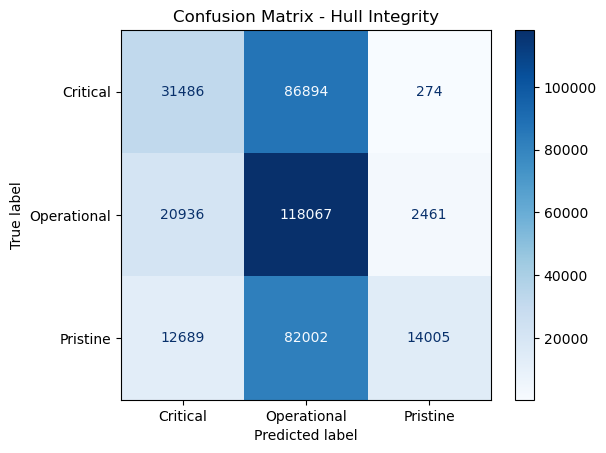

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = ["Critical", "Operational", "Pristine"]

cm = confusion_matrix(df["Hull_Integrity"], df["Predicted_Condition"], labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix - Hull Integrity")
plt.show()

---

## 5. Evaluation
*Rubric: LO 6.4C (Results vs. Objectives)*

**Assessment against succes criteria** 
*How well does your manual model identify 'Critical' or 'Pristine' ships? Did you meet the goals set in the Business Understanding?*

**Key findings and limitations**
*What are the limitations of a manual, hard-rule-based system? Why might a machine Learning model be better in the next iteration?*

Use [pandas' to_csv](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html) to export your cleaned and merged dataset for the next iteration. 

---

## 6 Personal Contribution
*Rubric: LO 7.3P (Equal Contribution)*

| Student name | Contribution | Personal lessons learned |
| :--- | :--- | :--- |
| Scott Mulder | Business Understanding & Data Understanding | I learned that alot of time is spent understanding the business logic. And then when you do understand it, it makes everything else go alot smoother, cause you understand what the cause is for doing your assignment. |
| Valentijn van Grunsven | Modeling | Hoe je een model kunt maken met If/Elif/Else statements die eigelijk best nog wel goed werkt. |
| Student name 3 | *Contribution description* | *Personal lessons learned this iteration* |